## Import Data

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd
df = pd.read_pickle('/content/drive/MyDrive/CPE393/consumer_complaint_dataset.data', compression='gzip')

## EDA

In [19]:
df.head()

,topic,input
0,Debt collection,transworld systems inc. \nis trying to collect...
1,"Credit reporting, credit repair services, or o...",I would like to request the suppression of the...
2,Debt collection,"Over the past 2 weeks, I have been receiving e..."
3,"Credit reporting, credit repair services, or o...",I HAD FILED WITH CFPB ON XX/XX/XXXX19 TO HAVE ...
4,"Credit reporting, credit repair services, or o...",I have several accounts that the balance is in...


In [20]:
df.shape

(492255, 2)

##Preprocess Text

In [21]:
df['sum'] = df['topic'] + ' ' + df['input']
df['sum'].head()

,sum
0,Debt collection transworld systems inc. \nis t...
1,"Credit reporting, credit repair services, or o..."
2,"Debt collection Over the past 2 weeks, I have ..."
3,"Credit reporting, credit repair services, or o..."
4,"Credit reporting, credit repair services, or o..."


In [22]:
input_text = df['sum'].tolist()

In [23]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [24]:
import re
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag


lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# remove masked info
def remove_masking(text):
    text = text.lower()
    masked_pattern = re.compile(r'xx+', re.IGNORECASE)
    return masked_pattern.sub('', text)

# POS tag
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# clean + tokenize + lemmatize
def clean_text(text: str):
    text = remove_masking(text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    pos_tags = pos_tag(tokens)

    lemmatized = [
        lemmatizer.lemmatize(w, get_wordnet_pos(tag))
        for w, tag in pos_tags if w not in stop_words
    ]
    return lemmatized

# ใช้กับ list ของข้อความ
def preprocess_text(text_list):
    return [clean_text(text) for text in text_list]


In [ ]:
text = preprocess_text(input_text)

In [ ]:
with open("/content/drive/MyDrive/CPE393/preprocess_text.txt", "w", encoding="utf-8") as f:
    for doc in text:
        f.write(" ".join(doc) + "\n")

## Import Preprocess Text From Lab 5



In [28]:
file_path = '/content/drive/MyDrive/CPE393/preprocess_text.txt'

with open(file_path, 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f.readlines()]
df['sum'] = lines
df.head()

,topic,input,sum
0,Debt collection,transworld systems inc. \nis trying to collect...,debt collection transworld system inc try coll...
1,"Credit reporting, credit repair services, or o...",I would like to request the suppression of the...,credit report credit repair service personal c...
2,Debt collection,"Over the past 2 weeks, I have been receiving e...",debt collection past week receive excessive am...
3,"Credit reporting, credit repair services, or o...",I HAD FILED WITH CFPB ON XX/XX/XXXX19 TO HAVE ...,credit report credit repair service personal c...
4,"Credit reporting, credit repair services, or o...",I have several accounts that the balance is in...,credit report credit repair service personal c...


## K-mean

### Before use K-mean

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['sum'])

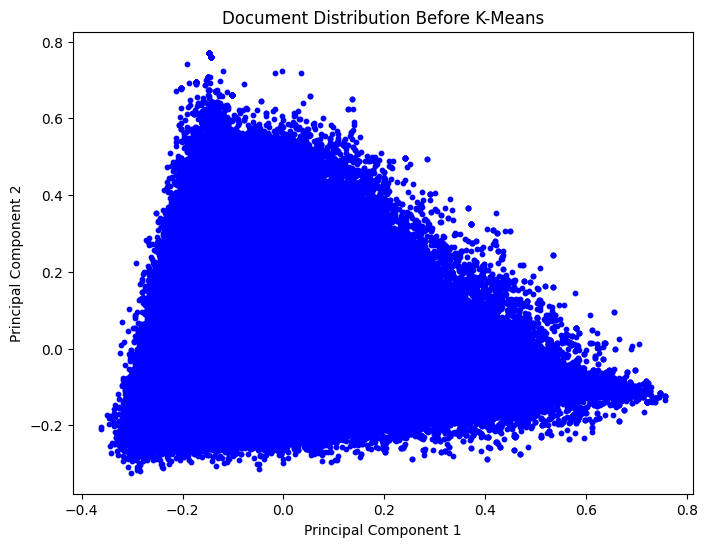

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X.toarray())

# Scatter plot ก่อน K-Means
plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:,0], X_reduced[:,1], s=10, color='blue')
plt.title("Document Distribution Before K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### After use K-mean (K=5)

In [31]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

df['cluster'] = kmeans.labels_


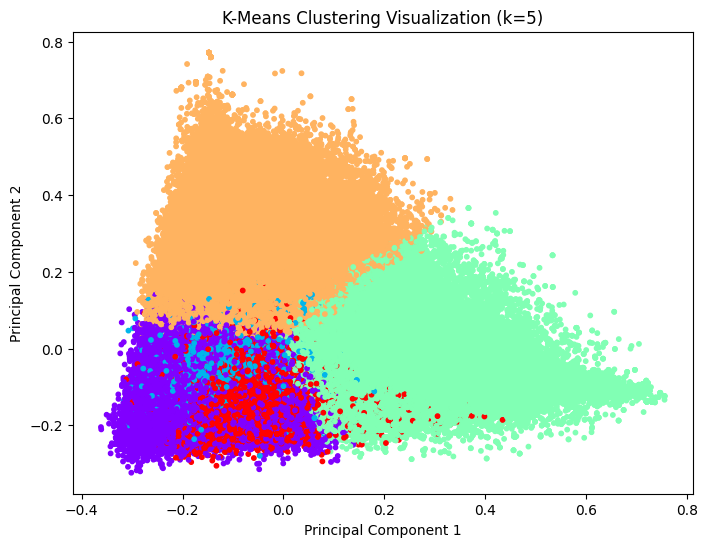

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ลดมิติ TF-IDF เหลือ 2 มิติ
pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X.toarray())

# Scatter plot ตาม cluster
plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=df['cluster'], cmap='rainbow', s=10)
plt.title(f"K-Means Clustering Visualization (k={k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [32]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]  # top 10 terms
    print(f"\nCluster {i}: {', '.join(top_terms)}")



Cluster 0: loan, payment, mortgage, pay, call, make, would, student, tell, get

Cluster 1: account, bank, check, money, saving, deposit, transfer, fee, fund, call

Cluster 2: report, credit, consumer, account, personal, repair, service, information, remove, inquiry

Cluster 3: debt, collection, call, credit, company, report, account, owe, receive, pay

Cluster 4: card, credit, charge, account, payment, call, pay, prepay, bank, balance


In [38]:
# แสดงตัวอย่างข้อความในแต่ละ cluster
for i in range(k):
    print(f"\nCluster {i} examples:")
    print(df['sum'][df['cluster']==i].head(5).to_list())


Cluster 0 examples:
['mortgage already try contact company following complaint time use different avenue recent email send request contact u least acknowledge complaint receive get response since complaint first file three week ago text submit complaint follow may concern write submit formal complaint regard poor service receive work close mark home loan strongly consider submit formal complaint consumer financial protection bureau similar state agency colorado andor california feel instance push boundary acceptable possible legal behavior entire loan process company start finish unprofessional best downright deceptive potentially lifeimpacting forget lie put stressful situation frankly never happen multiple account officer underwriter ask submit document multiple time tell falsehood upon complete close receive letter appear inform u deny loan close following summarized narrative timeline start prequalification process closing mortgage timeline compile base upon timestamped communicat

### After use K-mean (K= 3, 4, 7)

In [44]:
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

df['cluster'] = kmeans.labels_

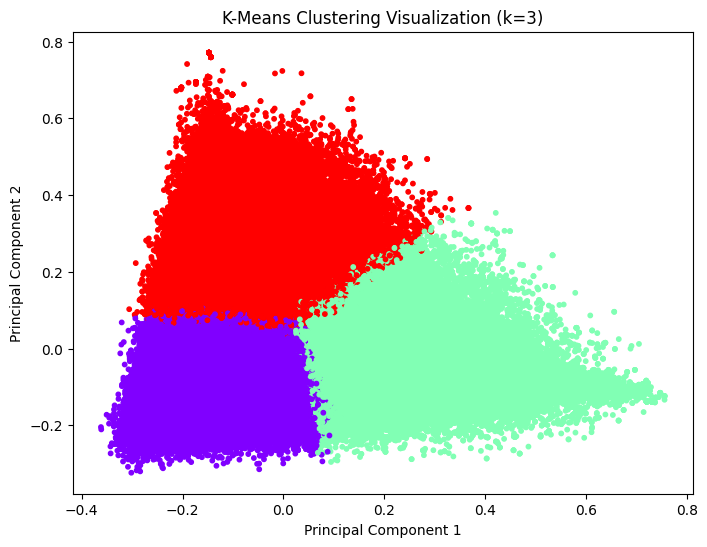

In [47]:
# ลดมิติ TF-IDF เหลือ 2 มิติ
pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X.toarray())

# Scatter plot ตาม cluster
plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=df['cluster'], cmap='rainbow', s=10)
plt.title(f"K-Means Clustering Visualization (k={k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [45]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]  # top 10 terms
    print(f"\nCluster {i}: {', '.join(top_terms)}")


Cluster 0: loan, payment, card, account, bank, mortgage, pay, call, credit, tell

Cluster 1: report, credit, consumer, account, personal, repair, service, information, remove, inquiry

Cluster 2: debt, collection, call, credit, company, report, account, owe, receive, letter


In [46]:
# แสดงตัวอย่างข้อความในแต่ละ cluster
for i in range(k):
    print(f"\nCluster {i} examples:")
    print(df['sum'][df['cluster']==i].head(5).to_list())


Cluster 0 examples:
['money transfer virtual currency money service sell access event digitally screenshots detail transaction transfer money provide fake ticket report paypal amount include fee paypal occur paypal user give two account', 'mortgage already try contact company following complaint time use different avenue recent email send request contact u least acknowledge complaint receive get response since complaint first file three week ago text submit complaint follow may concern write submit formal complaint regard poor service receive work close mark home loan strongly consider submit formal complaint consumer financial protection bureau similar state agency colorado andor california feel instance push boundary acceptable possible legal behavior entire loan process company start finish unprofessional best downright deceptive potentially lifeimpacting forget lie put stressful situation frankly never happen multiple account officer underwriter ask submit document multiple time t

In [48]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

df['cluster'] = kmeans.labels_

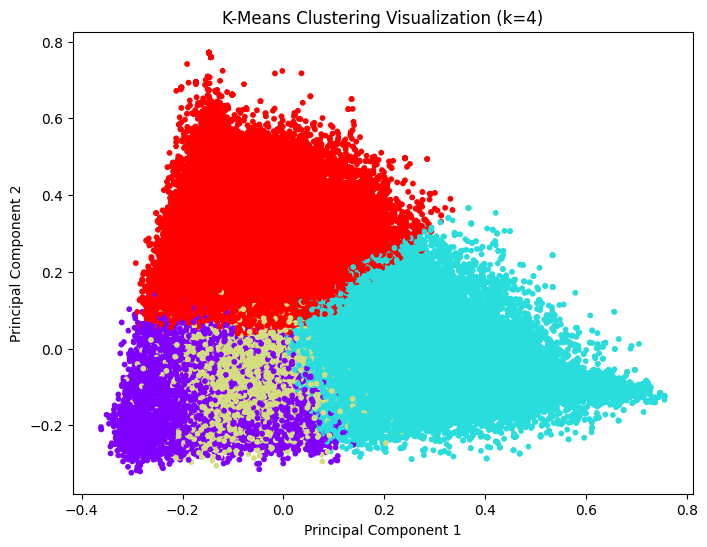

In [51]:
# ลดมิติ TF-IDF เหลือ 2 มิติ
pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X.toarray())

# Scatter plot ตาม cluster
plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=df['cluster'], cmap='rainbow', s=10)
plt.title(f"K-Means Clustering Visualization (k={k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [49]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]  # top 10 terms
    print(f"\nCluster {i}: {', '.join(top_terms)}")


Cluster 0: loan, payment, mortgage, pay, call, make, would, student, tell, get

Cluster 1: report, credit, consumer, account, personal, repair, service, information, remove, inquiry

Cluster 2: card, account, bank, credit, charge, check, money, call, fee, tell

Cluster 3: debt, collection, call, credit, company, report, account, owe, receive, pay


In [50]:
# แสดงตัวอย่างข้อความในแต่ละ cluster
for i in range(k):
    print(f"\nCluster {i} examples:")
    print(df['sum'][df['cluster']==i].head(5).to_list())


Cluster 0 examples:
['mortgage already try contact company following complaint time use different avenue recent email send request contact u least acknowledge complaint receive get response since complaint first file three week ago text submit complaint follow may concern write submit formal complaint regard poor service receive work close mark home loan strongly consider submit formal complaint consumer financial protection bureau similar state agency colorado andor california feel instance push boundary acceptable possible legal behavior entire loan process company start finish unprofessional best downright deceptive potentially lifeimpacting forget lie put stressful situation frankly never happen multiple account officer underwriter ask submit document multiple time tell falsehood upon complete close receive letter appear inform u deny loan close following summarized narrative timeline start prequalification process closing mortgage timeline compile base upon timestamped communicat

In [40]:
from sklearn.cluster import KMeans

k = 7
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

df['cluster'] = kmeans.labels_


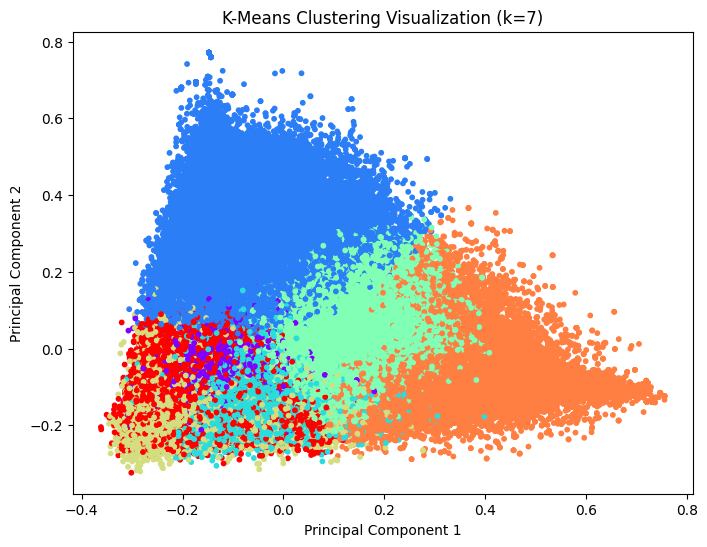

In [43]:
# ลดมิติ TF-IDF เหลือ 2 มิติ
pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X.toarray())

# Scatter plot ตาม cluster
plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=df['cluster'], cmap='rainbow', s=10)
plt.title(f"K-Means Clustering Visualization (k={k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [41]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]  # top 10 terms
    print(f"\nCluster {i}: {', '.join(top_terms)}")


Cluster 0: account, bank, check, money, saving, deposit, transfer, fee, fund, call

Cluster 1: debt, collection, call, company, credit, report, owe, account, pay, receive

Cluster 2: card, credit, charge, account, payment, call, pay, prepay, bank, balance

Cluster 3: credit, report, account, information, reporting, dispute, equifax, consumer, remove, personal

Cluster 4: loan, student, payment, pay, navient, interest, make, call, would, month

Cluster 5: report, credit, repair, personal, consumer, service, inquiry, account, remove, information

Cluster 6: mortgage, payment, loan, pay, call, home, make, would, tell, get


In [42]:
# แสดงตัวอย่างข้อความในแต่ละ cluster
for i in range(k):
    print(f"\nCluster {i} examples:")
    print(df['sum'][df['cluster']==i].head(5).to_list())


Cluster 0 examples:
['money transfer virtual currency money service sell access event digitally screenshots detail transaction transfer money provide fake ticket report paypal amount include fee paypal occur paypal user give two account', 'check saving account capital one mail closeout check around receive deposit account capital one chose place stop payment prematurely check error admit error plainly rather state expectation set correctly reason stop payment second check expedite via second day air rep allow enough mail time prior check reissue thus stop payment check amount represent remain balance check account end replacement check send deliver leave day address receivesign sign check pick drive statement mr state pick say date time please see attached document mr reach receive information leadership team capital one stating say check intercept sign live cash account bank capital one reply state person live address bank account link capital one account point also refer check depos